## Імпорт бібліотек

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

## Завантаження IMDB датасету

In [18]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

print(x_train.shape)
print(x_test.shape)

(25000,)
(25000,)


## Підготовка текстів

In [19]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print(x_train.shape)

(25000, 200)


# Модель RNN

In [20]:
model_rnn = keras.Sequential([
    layers.Embedding(max_features, 128, input_length=max_len),
    layers.SimpleRNN(64),
    layers.Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_rnn = model_rnn.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.6464 - loss: 0.5973 - val_accuracy: 0.8132 - val_loss: 0.4262
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.8632 - loss: 0.3271 - val_accuracy: 0.8260 - val_loss: 0.4369
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9170 - loss: 0.2150 - val_accuracy: 0.8350 - val_loss: 0.4376
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9790 - loss: 0.0686 - val_accuracy: 0.8202 - val_loss: 0.5361
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9919 - loss: 0.0309 - val_accuracy: 0.7862 - val_loss: 0.6741


## Перевірка

In [21]:
loss, acc = model_rnn.evaluate(x_test, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7916 - loss: 0.6549
Accuracy: 0.7915599942207336


# Модель LSTM

In [22]:
model_lstm = keras.Sequential([
    layers.Embedding(max_features, 128, input_length=max_len),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid")])

model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm = model_lstm.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 193ms/step - accuracy: 0.7614 - loss: 0.4964 - val_accuracy: 0.8422 - val_loss: 0.3751
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.8870 - loss: 0.2857 - val_accuracy: 0.8742 - val_loss: 0.3224
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 194ms/step - accuracy: 0.9257 - loss: 0.2072 - val_accuracy: 0.8596 - val_loss: 0.3520
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.9434 - loss: 0.1561 - val_accuracy: 0.8470 - val_loss: 0.3593
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 194ms/step - accuracy: 0.9592 - loss: 0.1160 - val_accuracy: 0.8546 - val_loss: 0.4151


## Перевірка

In [23]:
loss, acc = model_lstm.evaluate(x_test, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8525 - loss: 0.4145
Accuracy: 0.8524799942970276


# Модель Bidirectional LSTM

In [24]:
model_bilstm = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_bilstm = model_bilstm.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 504ms/step - accuracy: 0.7541 - loss: 0.4839 - val_accuracy: 0.8506 - val_loss: 0.3571
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 527ms/step - accuracy: 0.8922 - loss: 0.2653 - val_accuracy: 0.8628 - val_loss: 0.3250
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 521ms/step - accuracy: 0.9276 - loss: 0.1938 - val_accuracy: 0.8594 - val_loss: 0.3351
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 531ms/step - accuracy: 0.9488 - loss: 0.1434 - val_accuracy: 0.8442 - val_loss: 0.3632
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 136s 494ms/step - accuracy: 0.9595 - loss: 0.1125 - val_accuracy: 0.8554 - val_loss: 0.3871


## Перевірка

In [25]:
loss, acc = model_bilstm.evaluate(x_test, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8572 - loss: 0.3933
Accuracy: 0.857200026512146


# Модель глибока LSTM

In [26]:
model_deep = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")])

model_deep.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_deep = model_deep.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 298ms/step - accuracy: 0.7990 - loss: 0.4306 - val_accuracy: 0.8598 - val_loss: 0.3377
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 300ms/step - accuracy: 0.8999 - loss: 0.2540 - val_accuracy: 0.8686 - val_loss: 0.3112
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 304ms/step - accuracy: 0.9313 - loss: 0.1842 - val_accuracy: 0.8664 - val_loss: 0.3178
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 370ms/step - accuracy: 0.9550 - loss: 0.1305 - val_accuracy: 0.8536 - val_loss: 0.3997
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 408ms/step - accuracy: 0.9682 - loss: 0.0971 - val_accuracy: 0.8408 - val_loss: 0.4049


## Перевірка

In [28]:
loss, acc = model_deep.evaluate(x_test, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8404 - loss: 0.4115
Accuracy: 0.840399980545044


## Порівняння результатів

In [29]:
models = ["RNN", "LSTM", "Bidirectional LSTM", "Deep LSTM"]

results = []

for model in [model_rnn, model_lstm, model_bilstm, model_deep]:
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results.append(acc)

for name, acc in zip(models, results):
    print(name, ":", round(acc,4))

RNN : 0.7916
LSTM : 0.8525
Bidirectional LSTM : 0.8572
Deep LSTM : 0.8404


## Графік навчання

## Приклад для LSTM

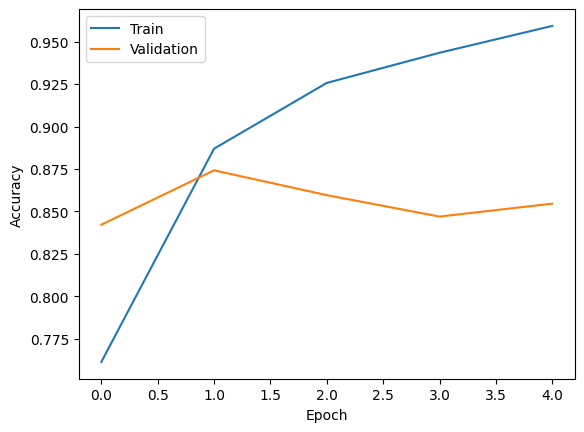

In [31]:
plt.plot(history_lstm.history["accuracy"])
plt.plot(history_lstm.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    ["Train", "Validation"]
)

plt.show()

## Висновки

In [ ]:
У ході виконання роботи було створено та протестовано декілька рекурентних нейронних мереж для задачі класифікації текстових рецензій із датасету IMDB.
Було проведено експерименти з різними архітектурами: звичайною RNN, LSTM, двонаправленою LSTM та глибокою LSTM мережею.
За результатами експериментів найнижчу точність показала проста RNN мережа — 0.7916. Це пояснюється тим, що звичайна рекурентна мережа має 
проблеми із збереженням інформації про попередні слова у довгих послідовностях, через що їй складніше враховувати повний контекст тексту.
Використання LSTM дозволило покращити результат до 0.8525. Це пов’язано з наявністю спеціального механізму пам’яті, який допомагає мережі краще 
зберігати важливу інформацію та враховувати довгострокові залежності між словами у рецензіях.
Найкращий результат серед усіх моделей отримала Bidirectional LSTM — 0.8572. Така архітектура аналізує текст у двох напрямках: від початку до 
кінця та від кінця до початку. Завдяки цьому модель отримує більше інформації про контекст слів і краще визначає емоційне забарвлення рецензій.
Глибока LSTM мережа показала точність 0.8404, що виявилося нижчим результатом порівняно зі звичайною LSTM та Bidirectional LSTM. 
Хоча збільшення кількості рекурентних шарів дозволяє моделі вивчати складніші залежності, у цьому випадку додаткова глибина не дала 
покращення. Це може бути пов’язано з недостатньою кількістю епох навчання, перенавчанням або тим, що для цього датасету більш проста 
архітектура краще узагальнює дані.
Отже, за результатами експериментів найефективнішою моделлю для класифікації рецензій IMDB стала Bidirectional LSTM з точністю 85.72%. 
LSTM-подібні архітектури показали кращі результати порівняно зі звичайною RNN, оскільки вони краще працюють із довгими текстовими послідовностями 
та здатні враховувати контекст слів.